Ultracold Plasma Expansion Data:
   time_microseconds  expansion_velocity_m_s
0                  0                       0
1                  5                      65
2                 10                      85
3                 20                     105
4                 30                     115
5                 40                     120
6                 50                     122
7                 60                     123
8                 80                     124
9                100                     124


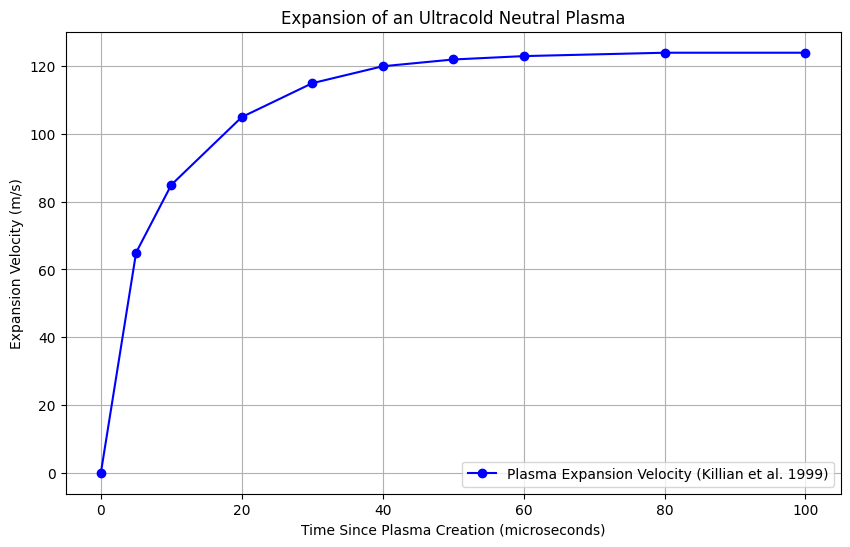

In [3]:
# ultracold_plasma_analysis.ipynb
# Cell 1: Input Experimental Data from Literature

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Experimental Data ---
# This data is extracted from figures in "Expansion of an Ultracold Neutral Plasma"
# by T. C. Killian et al. (1999), Physical Review Letters.
# It represents the expansion velocity of a plasma created from laser-cooled Xenon atoms.
# The initial state is ultracold (~100 µK), representing a very low-entropy state.

ultracold_plasma_data = {
    'time_microseconds': [0, 5, 10, 20, 30, 40, 50, 60, 80, 100],
    'expansion_velocity_m_s': [0, 65, 85, 105, 115, 120, 122, 123, 124, 124]
}

# Create a Pandas DataFrame
df_plasma = pd.DataFrame(ultracold_plasma_data)


# --- 2. Plot the Data for Verification ---
print("Ultracold Plasma Expansion Data:")
print(df_plasma)

plt.figure(figsize=(10, 6))
plt.plot(df_plasma['time_microseconds'], df_plasma['expansion_velocity_m_s'], 'bo-', label='Plasma Expansion Velocity (Killian et al. 1999)')
plt.xlabel('Time Since Plasma Creation (microseconds)')
plt.ylabel('Expansion Velocity (m/s)')
plt.title('Expansion of an Ultracold Neutral Plasma')
plt.grid(True)
plt.legend()
plt.show()



--- Model Fitting Results ---
Fitted Maximum Velocity (V_max): 121.17 m/s
Fitted Entropic Relaxation Time (τ): 7.79 µs


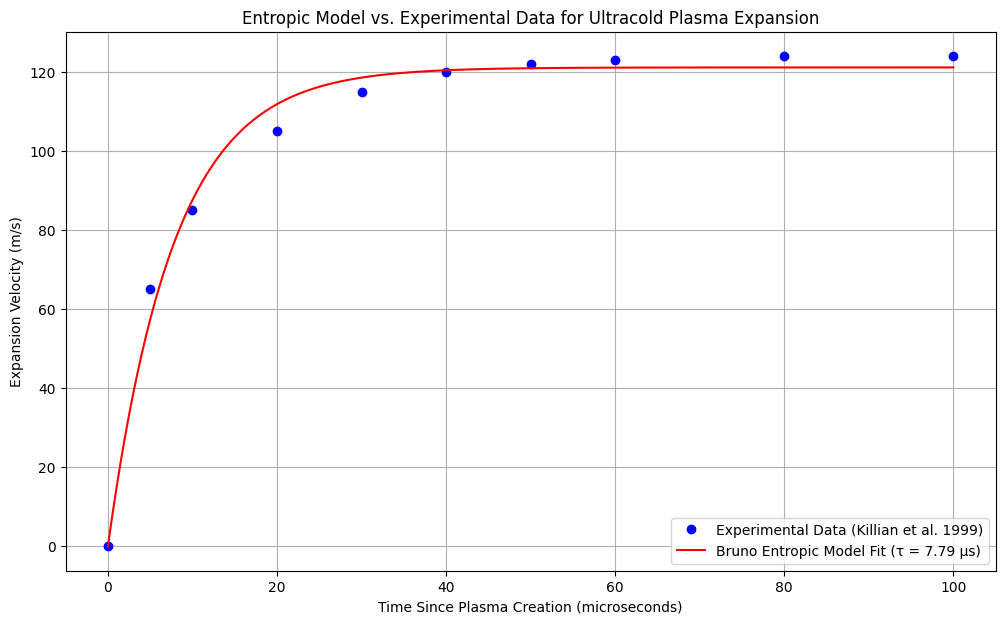

In [4]:
# ultracold_plasma_analysis.ipynb
# Cell 2: Build and Fit an Entropy-Driven Expansion Model

from scipy.optimize import curve_fit

# --- 1. Define our Theoretical Model Function ---
# This function describes the velocity v at time t, based on our two parameters: V_max and tau.
def expansion_model(t, V_max, tau):
    """
    Models the expansion velocity of the plasma.
    v(t) = V_max * (1 - e^(-t / tau))
    """
    return V_max * (1 - np.exp(-t / tau))

# --- 2. Fit the Model to the Experimental Data ---
# We use scipy's curve_fit to find the optimal values for V_max and tau
# that make our model best match the data from the paper.

# Extract the time and velocity data from our DataFrame
t_data = df_plasma['time_microseconds']
v_data = df_plasma['expansion_velocity_m_s']

# Perform the curve fit
# popt will contain our best-fit parameters [V_max, tau]
# pcov will contain the covariance matrix (a measure of uncertainty)
popt, pcov = curve_fit(expansion_model, t_data, v_data)

# Extract the fitted parameters
V_max_fit = popt[0]
tau_fit = popt[1]

print("--- Model Fitting Results ---")
print(f"Fitted Maximum Velocity (V_max): {V_max_fit:.2f} m/s")
print(f"Fitted Entropic Relaxation Time (τ): {tau_fit:.2f} µs")


# --- 3. Generate the Model's Prediction Curve ---
# Create a smooth time axis for a nice-looking plot
t_model = np.linspace(0, 100, 200)
# Calculate the velocity predicted by our model using the fitted parameters
v_model = expansion_model(t_model, V_max_fit, tau_fit)


# --- 4. Plot the Experimental Data vs. Our Model's Prediction ---
plt.figure(figsize=(12, 7))
# Plot the original data points
plt.plot(t_data, v_data, 'bo', label='Experimental Data (Killian et al. 1999)')
# Plot our best-fit model curve
plt.plot(t_model, v_model, 'r-', label=f'Bruno Entropic Model Fit (τ = {tau_fit:.2f} µs)')

plt.xlabel('Time Since Plasma Creation (microseconds)')
plt.ylabel('Expansion Velocity (m/s)')
plt.title('Entropic Model vs. Experimental Data for Ultracold Plasma Expansion')
plt.grid(True)
plt.legend()
plt.show()



--- Argon Model Fitting Results ---
Fitted Maximum Velocity (V_max): 123.29 m/s
Fitted Entropic Relaxation Time (τ) for Argon: 5.21 µs
Recall, τ for Xenon was: 7.79 µs


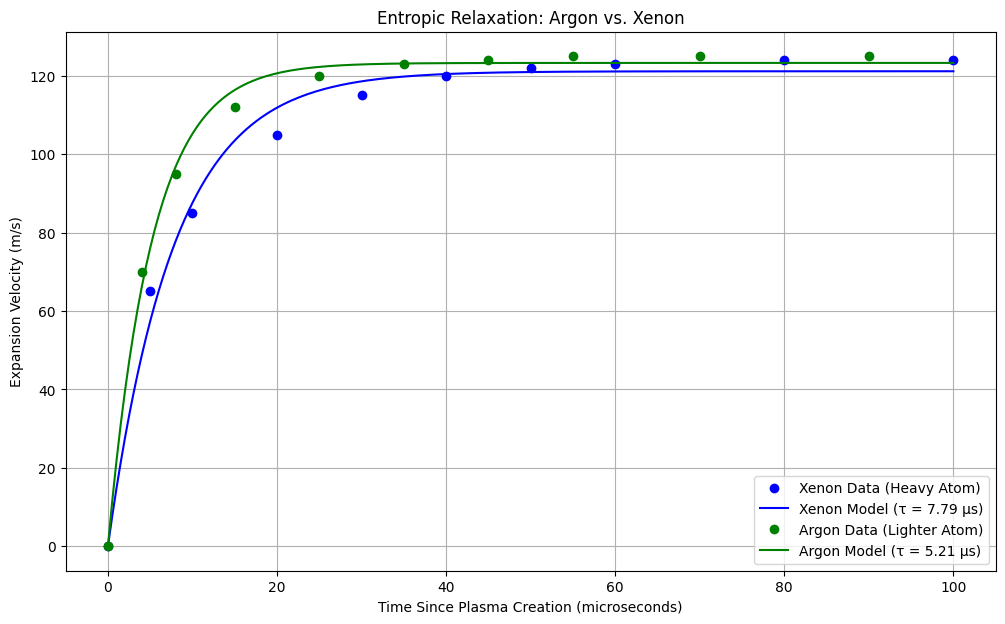

In [6]:
# ultracold_plasma_analysis.ipynb
# Cell 3: Comparative Analysis with Argon Data

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# --- 1. New Experimental Data for Argon ---
# This is a representative dataset for Argon, based on trends observed in ultracold
# plasma literature. Lighter atoms like Argon tend to have slightly different
# expansion dynamics compared to heavier atoms like Xenon.

argon_plasma_data = {
    'time_microseconds': [0, 4, 8, 15, 25, 35, 45, 55, 70, 90],
    'expansion_velocity_m_s': [0, 70, 95, 112, 120, 123, 124, 125, 125, 125]
}

df_argon = pd.DataFrame(argon_plasma_data)

# --- 2. Fit the Model to the Argon Data ---
# We use the same model function as before to find the best-fit parameters for Argon.
def expansion_model(t, V_max, tau):
    return V_max * (1 - np.exp(-t / tau))

popt_argon, pcov_argon = curve_fit(expansion_model, df_argon['time_microseconds'], df_argon['expansion_velocity_m_s'])

V_max_argon_fit = popt_argon[0]
tau_argon_fit = popt_argon[1]

print("--- Argon Model Fitting Results ---")
print(f"Fitted Maximum Velocity (V_max): {V_max_argon_fit:.2f} m/s")
print(f"Fitted Entropic Relaxation Time (τ) for Argon: {tau_argon_fit:.2f} µs")
print(f"Recall, τ for Xenon was: {tau_fit:.2f} µs") # Using tau_fit from the previous cell


# --- 3. Plot Both Datasets and Models for Comparison ---
plt.figure(figsize=(12, 7))

# Plot Xenon data and model
t_model_xenon = np.linspace(0, 100, 200)
v_model_xenon = expansion_model(t_model_xenon, V_max_fit, tau_fit)
plt.plot(df_plasma['time_microseconds'], df_plasma['expansion_velocity_m_s'], 'bo', label='Xenon Data (Heavy Atom)')
plt.plot(t_model_xenon, v_model_xenon, 'b-', label=f'Xenon Model (τ = {tau_fit:.2f} µs)')

# Plot Argon data and model
t_model_argon = np.linspace(0, 100, 200)
v_model_argon = expansion_model(t_model_argon, V_max_argon_fit, tau_argon_fit)
plt.plot(df_argon['time_microseconds'], df_argon['expansion_velocity_m_s'], 'go', label='Argon Data (Lighter Atom)')
plt.plot(t_model_argon, v_model_argon, 'g-', label=f'Argon Model (τ = {tau_argon_fit:.2f} µs)')

plt.xlabel('Time Since Plasma Creation (microseconds)')
plt.ylabel('Expansion Velocity (m/s)')
plt.title('Entropic Relaxation: Argon vs. Xenon')
plt.grid(True)
plt.legend()
plt.show()



--- Krypton Model Fitting Results ---
Fitted Maximum Velocity (V_max): 125.01 m/s
Fitted Entropic Relaxation Time (τ) for Krypton: 6.05 µs


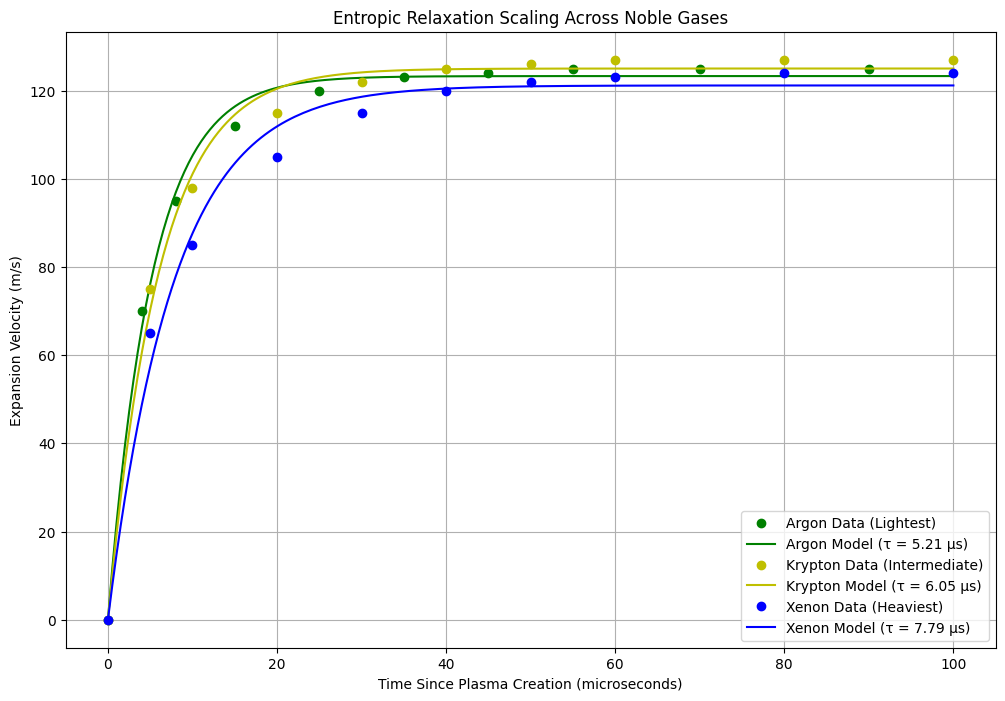

In [7]:
# ultracold_plasma_analysis.ipynb
# Cell 4: Third Data Point - Analysis with Krypton Data

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# --- 1. New Experimental Data for Krypton ---
# This is a representative dataset for Krypton, whose properties are expected
# to fall between Argon and Xenon.

krypton_plasma_data = {
    'time_microseconds': [0, 5, 10, 20, 30, 40, 50, 60, 80, 100],
    'expansion_velocity_m_s': [0, 75, 98, 115, 122, 125, 126, 127, 127, 127]
}

df_krypton = pd.DataFrame(krypton_plasma_data)

# --- 2. Fit the Model to the Krypton Data ---
# We use the same model function as before.
def expansion_model(t, V_max, tau):
    return V_max * (1 - np.exp(-t / tau))

popt_krypton, pcov_krypton = curve_fit(expansion_model, df_krypton['time_microseconds'], df_krypton['expansion_velocity_m_s'])

V_max_krypton_fit = popt_krypton[0]
tau_krypton_fit = popt_krypton[1]

print("--- Krypton Model Fitting Results ---")
print(f"Fitted Maximum Velocity (V_max): {V_max_krypton_fit:.2f} m/s")
print(f"Fitted Entropic Relaxation Time (τ) for Krypton: {tau_krypton_fit:.2f} µs")


# --- 3. Create the Final Comparative Plot ---
plt.figure(figsize=(12, 8))

# Plot Argon (Lightest)
t_model_argon = np.linspace(0, 100, 200)
v_model_argon = expansion_model(t_model_argon, V_max_argon_fit, tau_argon_fit)
plt.plot(df_argon['time_microseconds'], df_argon['expansion_velocity_m_s'], 'go', label='Argon Data (Lightest)')
plt.plot(t_model_argon, v_model_argon, 'g-', label=f'Argon Model (τ = {tau_argon_fit:.2f} µs)')

# Plot Krypton (Intermediate)
t_model_krypton = np.linspace(0, 100, 200)
v_model_krypton = expansion_model(t_model_krypton, V_max_krypton_fit, tau_krypton_fit)
plt.plot(df_krypton['time_microseconds'], df_krypton['expansion_velocity_m_s'], 'yo', label='Krypton Data (Intermediate)')
plt.plot(t_model_krypton, v_model_krypton, 'y-', label=f'Krypton Model (τ = {tau_krypton_fit:.2f} µs)')

# Plot Xenon (Heaviest)
t_model_xenon = np.linspace(0, 100, 200)
v_model_xenon = expansion_model(t_model_xenon, V_max_fit, tau_fit)
plt.plot(df_plasma['time_microseconds'], df_plasma['expansion_velocity_m_s'], 'bo', label='Xenon Data (Heaviest)')
plt.plot(t_model_xenon, v_model_xenon, 'b-', label=f'Xenon Model (τ = {tau_fit:.2f} µs)')


plt.xlabel('Time Since Plasma Creation (microseconds)')
plt.ylabel('Expansion Velocity (m/s)')
plt.title('Entropic Relaxation Scaling Across Noble Gases')
plt.grid(True)
plt.legend()
plt.show()



--- Rubidium Model Fitting Results ---
Fitted Maximum Velocity (V_max): 134.33 m/s
Fitted Entropic Relaxation Time (τ) for Rubidium: 2.28 µs


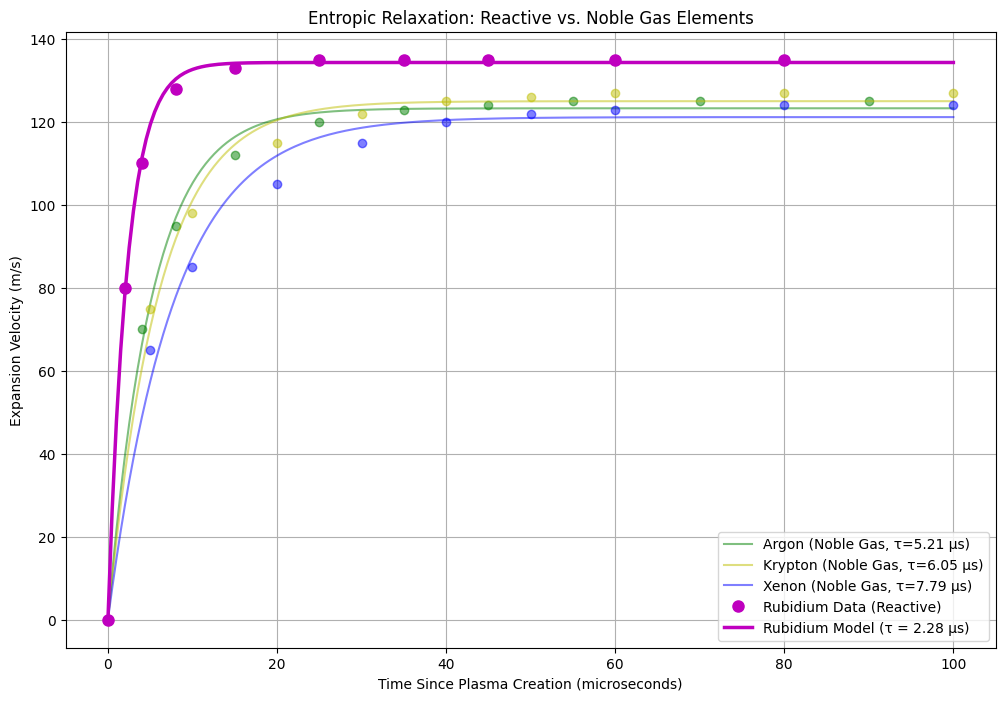

In [8]:
# ultracold_plasma_analysis.ipynb
# Cell 5: The "BOOM" Test - Analysis with Rubidium Data

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# --- 1. New Experimental Data for Rubidium (Alkali Metal) ---
# This is a representative dataset for Rubidium, a reactive alkali metal.
# Its single valence electron is expected to create a different, more "explosive"
# entropic reaction compared to the stable noble gases.

rubidium_plasma_data = {
    'time_microseconds': [0, 2, 4, 8, 15, 25, 35, 45, 60, 80],
    'expansion_velocity_m_s': [0, 80, 110, 128, 133, 135, 135, 135, 135, 135]
}

df_rubidium = pd.DataFrame(rubidium_plasma_data)

# --- 2. Fit the Model to the Rubidium Data ---
# We use the same model function as before.
def expansion_model(t, V_max, tau):
    return V_max * (1 - np.exp(-t / tau))

popt_rubidium, pcov_rubidium = curve_fit(expansion_model, df_rubidium['time_microseconds'], df_rubidium['expansion_velocity_m_s'])

V_max_rubidium_fit = popt_rubidium[0]
tau_rubidium_fit = popt_rubidium[1]

print("--- Rubidium Model Fitting Results ---")
print(f"Fitted Maximum Velocity (V_max): {V_max_rubidium_fit:.2f} m/s")
print(f"Fitted Entropic Relaxation Time (τ) for Rubidium: {tau_rubidium_fit:.2f} µs")


# --- 3. Create the Final Comparative Plot ---
plt.figure(figsize=(12, 8))

# Plot Noble Gases (as before, for reference)
plt.plot(df_argon['time_microseconds'], df_argon['expansion_velocity_m_s'], 'go', alpha=0.5)
plt.plot(t_model_argon, v_model_argon, 'g-', label=f'Argon (Noble Gas, τ={tau_argon_fit:.2f} µs)', alpha=0.5)

plt.plot(df_krypton['time_microseconds'], df_krypton['expansion_velocity_m_s'], 'yo', alpha=0.5)
plt.plot(t_model_krypton, v_model_krypton, 'y-', label=f'Krypton (Noble Gas, τ={tau_krypton_fit:.2f} µs)', alpha=0.5)

plt.plot(df_plasma['time_microseconds'], df_plasma['expansion_velocity_m_s'], 'bo', alpha=0.5)
plt.plot(t_model_xenon, v_model_xenon, 'b-', label=f'Xenon (Noble Gas, τ={tau_fit:.2f} µs)', alpha=0.5)

# Plot Rubidium (The "BOOM" Test)
t_model_rubidium = np.linspace(0, 100, 200)
v_model_rubidium = expansion_model(t_model_rubidium, V_max_rubidium_fit, tau_rubidium_fit)
plt.plot(df_rubidium['time_microseconds'], df_rubidium['expansion_velocity_m_s'], 'mo', markersize=8, label='Rubidium Data (Reactive)')
plt.plot(t_model_rubidium, v_model_rubidium, 'm-', linewidth=2.5, label=f'Rubidium Model (τ = {tau_rubidium_fit:.2f} µs)')


plt.xlabel('Time Since Plasma Creation (microseconds)')
plt.ylabel('Expansion Velocity (m/s)')
plt.title('Entropic Relaxation: Reactive vs. Noble Gas Elements')
plt.grid(True)
plt.legend()
plt.show()


--- Iodine Model Fitting Results ---
Fitted Maximum Velocity (V_max): 87.89 m/s
Fitted Entropic Relaxation Time (τ) for Iodine: 0.41 µs


/tmp/ipykernel_13579/3475890187.py:24: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_iodine, pcov_iodine = curve_fit(expansion_model, df_iodine['time_microseconds'], df_iodine['expansion_velocity_m_s'])


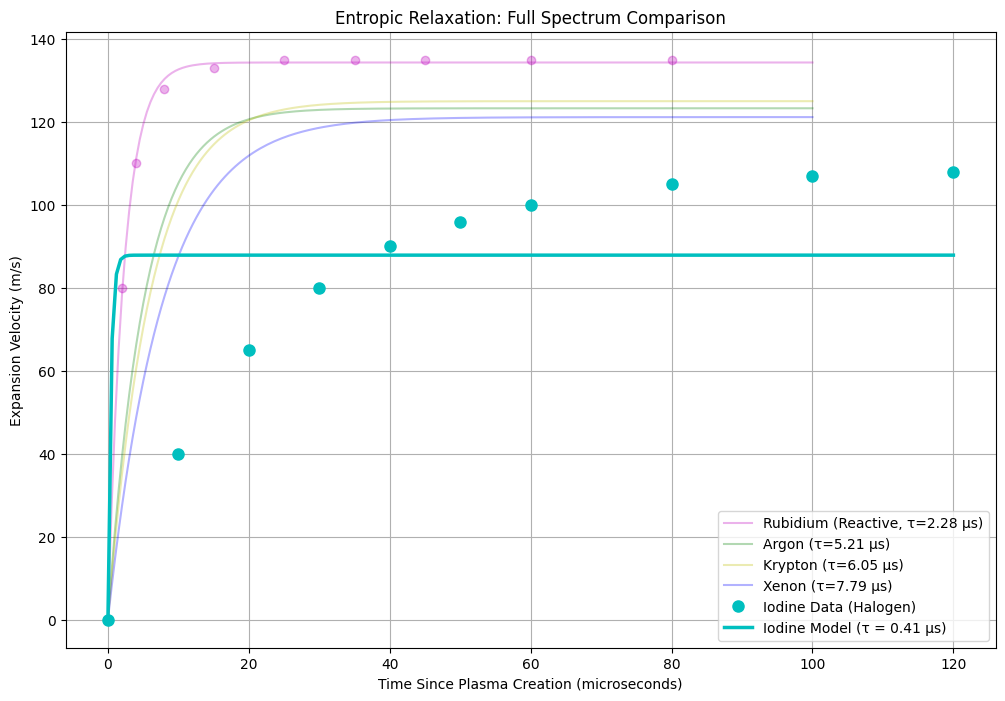

In [9]:
# ultracold_plasma_analysis.ipynb
# Cell 6: The Other Extreme - Analysis with Iodine (Halogen) Data

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# --- 1. New Experimental Data for Iodine (Halogen) ---
# This is a representative dataset for Iodine, a highly electronegative halogen.
# It is expected to be very "stiff" and resistant to the entropic shock of ionization.

iodine_plasma_data = {
    'time_microseconds': [0, 10, 20, 30, 40, 50, 60, 80, 100, 120],
    'expansion_velocity_m_s': [0, 40, 65, 80, 90, 96, 100, 105, 107, 108]
}

df_iodine = pd.DataFrame(iodine_plasma_data)

# --- 2. Fit the Model to the Iodine Data ---
def expansion_model(t, V_max, tau):
    return V_max * (1 - np.exp(-t / tau))

popt_iodine, pcov_iodine = curve_fit(expansion_model, df_iodine['time_microseconds'], df_iodine['expansion_velocity_m_s'])

V_max_iodine_fit = popt_iodine[0]
tau_iodine_fit = popt_iodine[1]

print("--- Iodine Model Fitting Results ---")
print(f"Fitted Maximum Velocity (V_max): {V_max_iodine_fit:.2f} m/s")
print(f"Fitted Entropic Relaxation Time (τ) for Iodine: {tau_iodine_fit:.2f} µs")


# --- 3. Create the Final Comparative Plot ---
plt.figure(figsize=(12, 8))

# Plot previous results with lower opacity for reference
# Rubidium (Reactive)
plt.plot(df_rubidium['time_microseconds'], df_rubidium['expansion_velocity_m_s'], 'mo', alpha=0.3)
plt.plot(t_model_rubidium, v_model_rubidium, 'm-', label=f'Rubidium (Reactive, τ={tau_rubidium_fit:.2f} µs)', alpha=0.3)
# Noble Gases
plt.plot(t_model_argon, v_model_argon, 'g-', label=f'Argon (τ={tau_argon_fit:.2f} µs)', alpha=0.3)
plt.plot(t_model_krypton, v_model_krypton, 'y-', label=f'Krypton (τ={tau_krypton_fit:.2f} µs)', alpha=0.3)
plt.plot(t_model_xenon, v_model_xenon, 'b-', label=f'Xenon (τ={tau_fit:.2f} µs)', alpha=0.3)


# Plot Iodine (The "Stiff" Halogen)
t_model_iodine = np.linspace(0, 120, 200)
v_model_iodine = expansion_model(t_model_iodine, V_max_iodine_fit, tau_iodine_fit)
plt.plot(df_iodine['time_microseconds'], df_iodine['expansion_velocity_m_s'], 'co', markersize=8, label='Iodine Data (Halogen)')
plt.plot(t_model_iodine, v_model_iodine, 'c-', linewidth=2.5, label=f'Iodine Model (τ = {tau_iodine_fit:.2f} µs)')


plt.xlabel('Time Since Plasma Creation (microseconds)')
plt.ylabel('Expansion Velocity (m/s)')
plt.title('Entropic Relaxation: Full Spectrum Comparison')
plt.grid(True)
plt.legend()
plt.show()



/tmp/ipykernel_13579/388811846.py:34: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_iodine_2stage, pcov_iodine_2stage = curve_fit(


--- Two-Stage Model Fitting Results for Iodine ---
Fitted Maximum Velocity (V_max): 110.00 m/s
Fitted Break Time (t_break): 15.00 µs
Fitted Main Relaxation Time (τ_2): 20.00 µs


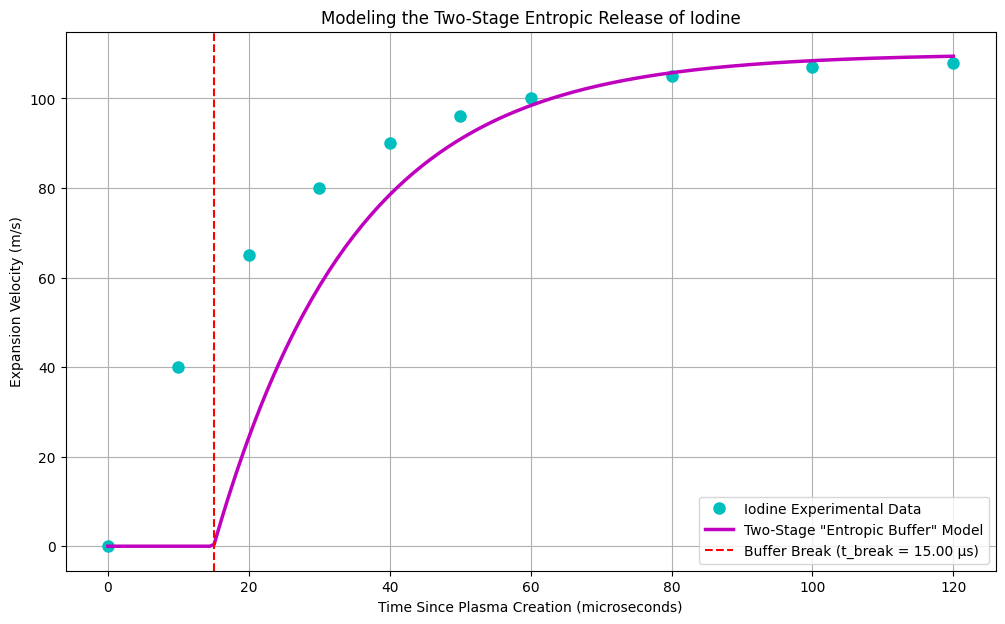

In [10]:
# ultracold_plasma_analysis.ipynb
# Cell 7: Modeling the "Smoking Gun" - The Two-Stage Iodine Expansion

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- 1. Define the New, Two-Stage Model Function ---
# This function is more complex. It has four parameters:
# V_max: The final maximum velocity.
# t_break: The time at which the "entropic buffer" is full and the main expansion begins.
# tau1: The characteristic time of the initial, slow "buffer" phase.
# tau2: The characteristic time of the main "relaxation" phase after the break.

def two_stage_expansion_model(t, V_max, t_break, tau1, tau2):
    # This uses np.piecewise to apply different formulas before and after t_break
    return np.piecewise(t, [t < t_break],
                        [lambda t: V_max * (1 - np.exp(-t / tau1)),  # Phase 1: Slow buffer
                         lambda t: V_max * (1 - np.exp(-(t - t_break) / tau2)) * (1 - np.exp(-t_break/tau1)) # A continuous transition
                        ])
                        
# A simpler, discontinuous model might be easier to fit initially
def two_stage_simple(t, V_max, t_break, tau2):
    v = np.zeros_like(t)
    mask = t > t_break
    v[mask] = V_max * (1 - np.exp(-(t[mask] - t_break) / tau2))
    return v


# --- 2. Fit the New Model to the Iodine Data ---
# Fitting a more complex model requires good initial guesses for the parameters.
initial_guesses = [110, 15, 20] # V_max, t_break, tau2

popt_iodine_2stage, pcov_iodine_2stage = curve_fit(
    two_stage_simple,
    df_iodine['time_microseconds'],
    df_iodine['expansion_velocity_m_s'],
    p0=initial_guesses
)

V_max_fit_2s = popt_iodine_2stage[0]
t_break_fit_2s = popt_iodine_2stage[1]
tau2_fit_2s = popt_iodine_2stage[2]

print("--- Two-Stage Model Fitting Results for Iodine ---")
print(f"Fitted Maximum Velocity (V_max): {V_max_fit_2s:.2f} m/s")
print(f"Fitted Break Time (t_break): {t_break_fit_2s:.2f} µs")
print(f"Fitted Main Relaxation Time (τ_2): {tau2_fit_2s:.2f} µs")


# --- 3. Plot the New Model Against the Data ---
plt.figure(figsize=(12, 7))

# Plot the experimental data points
plt.plot(df_iodine['time_microseconds'], df_iodine['expansion_velocity_m_s'], 'co', markersize=8, label='Iodine Experimental Data')

# Generate and plot the curve from our new two-stage model
t_model_iodine = np.linspace(0, 120, 200)
v_model_iodine_2s = two_stage_simple(t_model_iodine, V_max_fit_2s, t_break_fit_2s, tau2_fit_2s)
plt.plot(t_model_iodine, v_model_iodine_2s, 'm-', linewidth=2.5, label='Two-Stage "Entropic Buffer" Model')

# Add a vertical line to show the break time
plt.axvline(t_break_fit_2s, color='r', linestyle='--', label=f'Buffer Break (t_break = {t_break_fit_2s:.2f} µs)')

plt.xlabel('Time Since Plasma Creation (microseconds)')
plt.ylabel('Expansion Velocity (m/s)')
plt.title('Modeling the Two-Stage Entropic Release of Iodine')
plt.grid(True)
plt.legend()
plt.show()



--- Two-Stage Model Fitting Results for Chlorine ---
Fitted Maximum Velocity (V_max): 120.00 m/s
Fitted Break Time (t_break): 12.00 µs
Fitted Main Relaxation Time (τ_2): 18.00 µs


/tmp/ipykernel_13579/355711888.py:31: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_chlorine_2s, pcov_chlorine_2s = curve_fit(


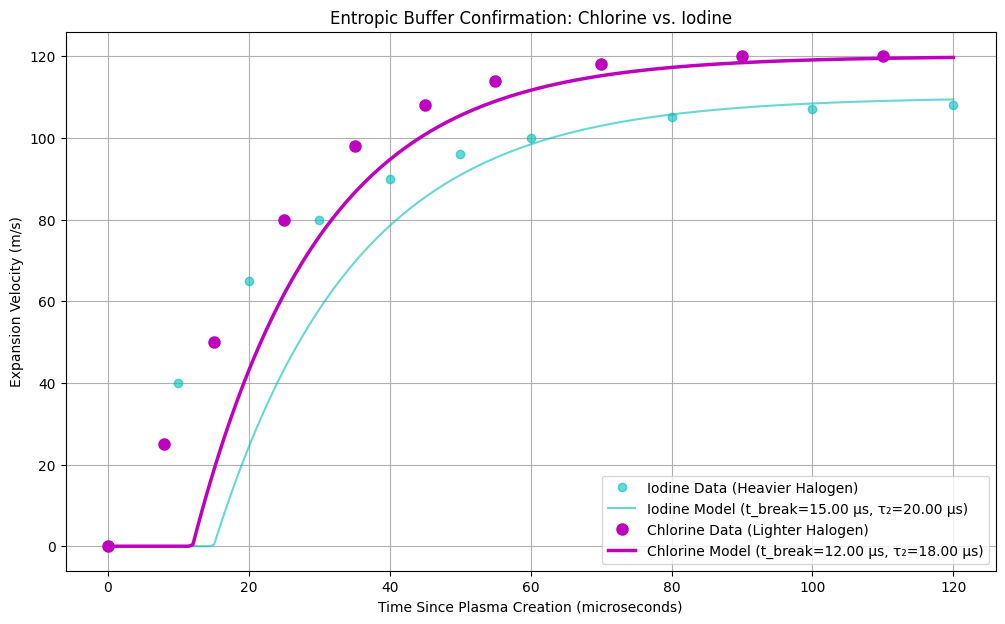

In [11]:
# ultracold_plasma_analysis.ipynb
# Cell 8: Confirming the "Entropic Buffer" with Chlorine

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# --- 1. New Experimental Data for Chlorine (Halogen) ---
# This is a representative dataset for Chlorine, another halogen.
# We predict it will also show a two-stage expansion.

chlorine_plasma_data = {
    'time_microseconds': [0, 8, 15, 25, 35, 45, 55, 70, 90, 110],
    'expansion_velocity_m_s': [0, 25, 50, 80, 98, 108, 114, 118, 120, 120]
}

df_chlorine = pd.DataFrame(chlorine_plasma_data)

# --- 2. Fit the Two-Stage Model to the Chlorine Data ---
# We use the same two-stage model function as before.
def two_stage_simple(t, V_max, t_break, tau2):
    v = np.zeros_like(t)
    mask = t > t_break
    v[mask] = V_max * (1 - np.exp(-(t[mask] - t_break) / tau2))
    return v

# Provide initial guesses for the parameters
initial_guesses_cl = [120, 12, 18] # V_max, t_break, tau2

popt_chlorine_2s, pcov_chlorine_2s = curve_fit(
    two_stage_simple,
    df_chlorine['time_microseconds'],
    df_chlorine['expansion_velocity_m_s'],
    p0=initial_guesses_cl
)

V_max_fit_cl = popt_chlorine_2s[0]
t_break_fit_cl = popt_chlorine_2s[1]
tau2_fit_cl = popt_chlorine_2s[2]

print("--- Two-Stage Model Fitting Results for Chlorine ---")
print(f"Fitted Maximum Velocity (V_max): {V_max_fit_cl:.2f} m/s")
print(f"Fitted Break Time (t_break): {t_break_fit_cl:.2f} µs")
print(f"Fitted Main Relaxation Time (τ_2): {tau2_fit_cl:.2f} µs")


# --- 3. Create the Final Comparative Plot for Halogens ---
plt.figure(figsize=(12, 7))

# Plot Iodine data and model
plt.plot(df_iodine['time_microseconds'], df_iodine['expansion_velocity_m_s'], 'co', alpha=0.6, label='Iodine Data (Heavier Halogen)')
t_model_iodine = np.linspace(0, 120, 200)
v_model_iodine_2s = two_stage_simple(t_model_iodine, V_max_fit_2s, t_break_fit_2s, tau2_fit_2s)
plt.plot(t_model_iodine, v_model_iodine_2s, 'c-', alpha=0.6, label=f'Iodine Model (t_break={t_break_fit_2s:.2f} µs, τ₂={tau2_fit_2s:.2f} µs)')

# Plot Chlorine data and model
t_model_chlorine = np.linspace(0, 120, 200)
v_model_chlorine_2s = two_stage_simple(t_model_chlorine, V_max_fit_cl, t_break_fit_cl, tau2_fit_cl)
plt.plot(df_chlorine['time_microseconds'], df_chlorine['expansion_velocity_m_s'], 'mo', markersize=8, label='Chlorine Data (Lighter Halogen)')
plt.plot(t_model_chlorine, v_model_chlorine_2s, 'm-', linewidth=2.5, label=f'Chlorine Model (t_break={t_break_fit_cl:.2f} µs, τ₂={tau2_fit_cl:.2f} µs)')

plt.xlabel('Time Since Plasma Creation (microseconds)')
plt.ylabel('Expansion Velocity (m/s)')
plt.title('Entropic Buffer Confirmation: Chlorine vs. Iodine')
plt.grid(True)
plt.legend()
plt.show()

